In [1]:
import joblib

import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

import librosa
import textwrap

from birdclef_2026_ml.processing.memmap_dataset import load_memmap_dataset
from birdclef_2026_ml.notebooks.notebook_utils import init_notebook
from birdclef_2026_ml.paths import load_project_paths
from birdclef_2026_ml.configs import FeatureConfig
from birdclef_2026_ml.feature_engineering.feature_extract import *
from birdclef_2026_ml.feature_engineering.feature_extract import compute_profile_similarity_features
from birdclef_2026_ml.feature_engineering.profiles import get_feature_indices

feat_cfg = FeatureConfig()
paths = load_project_paths()
init_notebook()

In [2]:
train_df = pd.read_parquet(paths.train_processed) 
taxonomy = pd.read_csv(paths.taxonomy)
# primary_to_class = le_class_name.inverse_transform(primary_to_class)
# species_ids = le_primary_label.inverse_transform(species_ids)

In [3]:
def sample_primary_label(plot_df, class_name, n=10):
    np.random.seed(42)
    all_labels = plot_df.loc[plot_df["class_name"] == class_name, "primary_label"].unique()
    labels = np.random.choice(all_labels, size=min(n, len(all_labels)), replace=False)
    
    return plot_df[plot_df["primary_label"].isin(labels)]

def get_dominant_hist(
    filenames,
    feature_dir,
    n_mels=128,
):
    hists = []

    for filename in filenames:
        path = (feature_dir / filename).with_suffix(".npy")
        S = np.load(path)  # shape: (n_mels, n_frames)

        dominants = np.argmax(S, axis=0)
        hist, _ = np.histogram(
            dominants,
            bins=np.arange(n_mels + 1),
            density=False,
        )
        hists.append(hist)

    # normalize for probability distribution
    return np.mean(hists, axis=0) 

def build_plot_df(profiles):
    freqs = librosa.mel_frequencies(n_mels=128)
    plot_df = profiles.copy()

    plot_df["mel_frequencies"] = [freqs.tolist()] * len(plot_df)
    plot_df["dominant_hist"] = plot_df["dominant_hist"].apply(
        lambda x: np.asarray(x).tolist()
    )

    plot_df = plot_df.explode(
        ["mel_frequencies", "dominant_hist"],
        ignore_index=True,
    )

    plot_df["mel_frequencies"] = plot_df["mel_frequencies"].astype(float)
    plot_df["dominant_hist"] = plot_df["dominant_hist"].astype(float)

    return plot_df

def plot_kde(plot_df, hue_col):
    g = sns.FacetGrid(
        plot_df,
        row=hue_col,
        hue=hue_col,
        aspect=10,
        height=1,
        palette="viridis",
        sharex=True,
        sharey=False,
    )

    g.map_dataframe(
        sns.kdeplot,
        x="mel_frequencies",
        weights="dominant_hist",
        bw_adjust=0.5,
        fill=True,
        alpha=0.9,
        linewidth=1.0,
        common_norm=False,
        clip=(
            plot_df["mel_frequencies"].min(),
            plot_df["mel_frequencies"].max(),
        ),
    )

    g.map_dataframe(
        sns.kdeplot,
        x="mel_frequencies",
        weights="dominant_hist",
        bw_adjust=0.5,
        color="white",
        linewidth=0.8,
        common_norm=False,
    )

    g.refline(
        y=0,
        linewidth=2,
        linestyle="-",
        color=None,
        clip_on=False,
    )

    g.refline(y=0, linewidth=2, linestyle="-", color=None, clip_on=False)

    def label(x, color, label):
        ax = plt.gca()
        label_wrapped = "\n".join(textwrap.wrap(label, width=20))
        ax.text(0, .2, label_wrapped, fontweight="bold", color=color, fontsize=10,
                ha="left", va="center", transform=ax.transAxes)

    
    g.map(label, "mel_frequencies")

    # Set the subplots to overlap
    # Remove axes details that don't play well with overlap
    g.set_titles("")
    g.figure.suptitle(f"Dominant-frequency KDE by {hue_col}", fontsize=13)
    g.set(yticks=[], ylabel="")
    g.despine(bottom=True, left=True)
    g.set_xlabels("Frequency (Hz)")
    plt.tight_layout()

    return g.figure

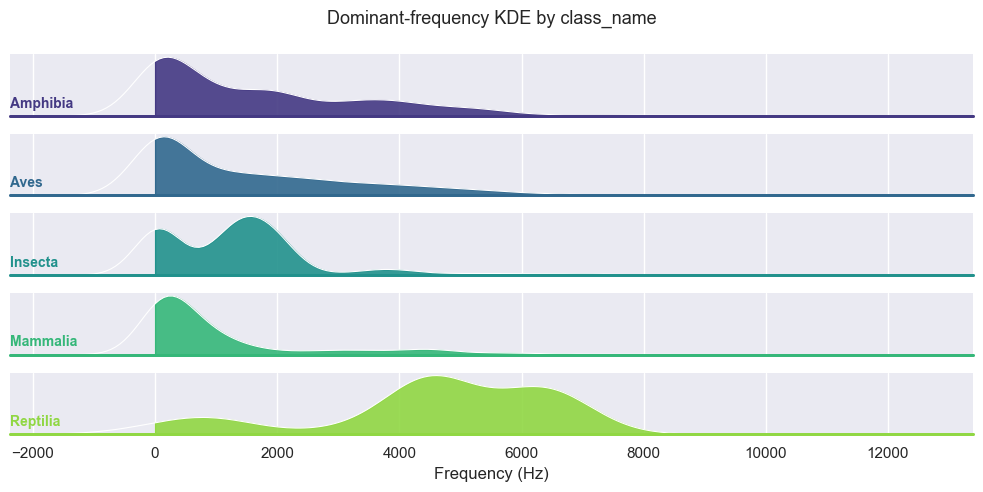

In [4]:
class_profiles = (
    train_df.groupby("class_name")["filename"]
    .apply(
        lambda x: get_dominant_hist(
            filenames=x,
            feature_dir=paths.feature_dir("train", "mel"),
            n_mels=128,
        )
    )
    .reset_index(name="dominant_hist")
)

plot_df = build_plot_df(class_profiles)
fig = plot_kde(plot_df, "class_name")
fig.savefig("plots/profiles/class_kde.pdf", bbox_inches="tight")

In [5]:
label_profiles = (
    train_df.groupby("primary_label")["filename"]
    .apply(
        lambda x: get_dominant_hist(
            filenames=x,
            feature_dir=paths.feature_dir("train", "mel"),
            n_mels=128,
        )
    )
    .reset_index(name="dominant_hist")
)
plot_df = build_plot_df(label_profiles)
plot_df = plot_df.merge(taxonomy[["primary_label", "class_name", "common_name"]], on="primary_label")

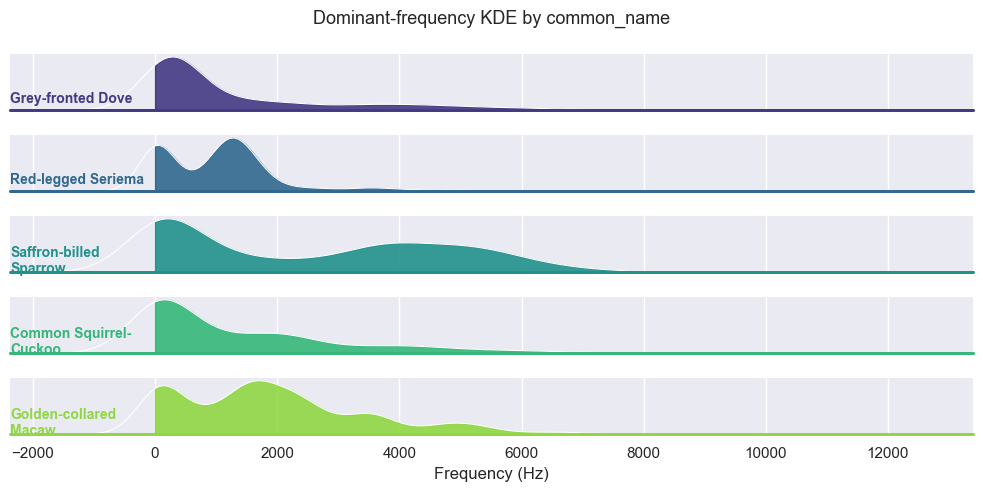

In [6]:
plot_df_subset = sample_primary_label(plot_df, "Aves", n=5)
fig = plot_kde(plot_df_subset, "common_name")
fig.savefig("plots/profiles/kde_aves.pdf", bbox_inches="tight")

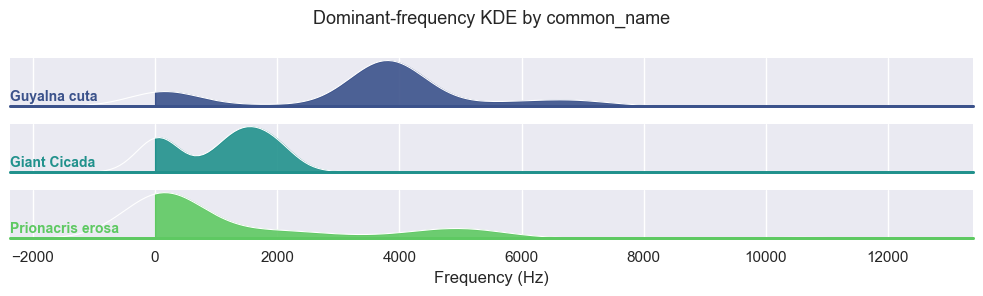

In [7]:
plot_df_subset = sample_primary_label(plot_df, "Insecta", n=5)
fig = plot_kde(plot_df_subset, "common_name")
fig.savefig("plots/profiles/kde_insecta.pdf", bbox_inches="tight")

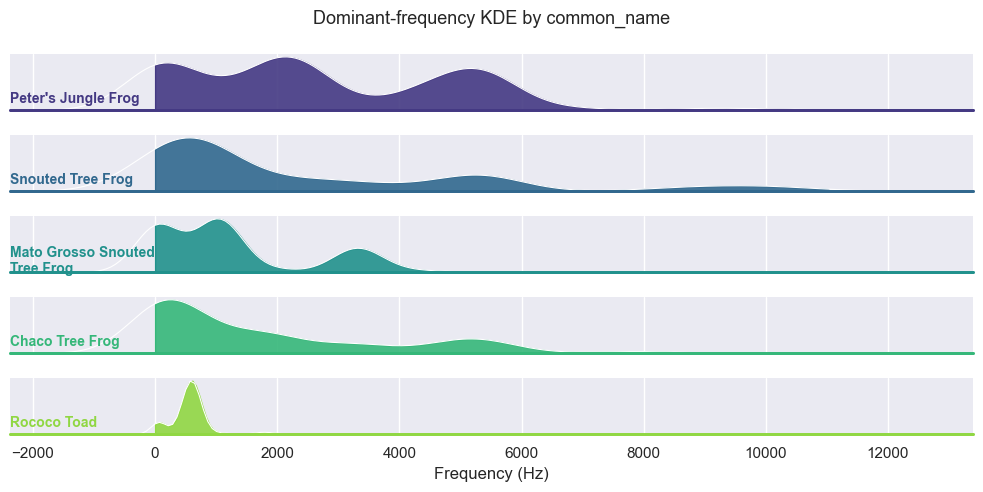

In [8]:
plot_df_subset = sample_primary_label(plot_df, "Amphibia", n=5)
fig = plot_kde(plot_df_subset, "common_name")
fig.savefig("plots/profiles/kde_amphibia.pdf", bbox_inches="tight")

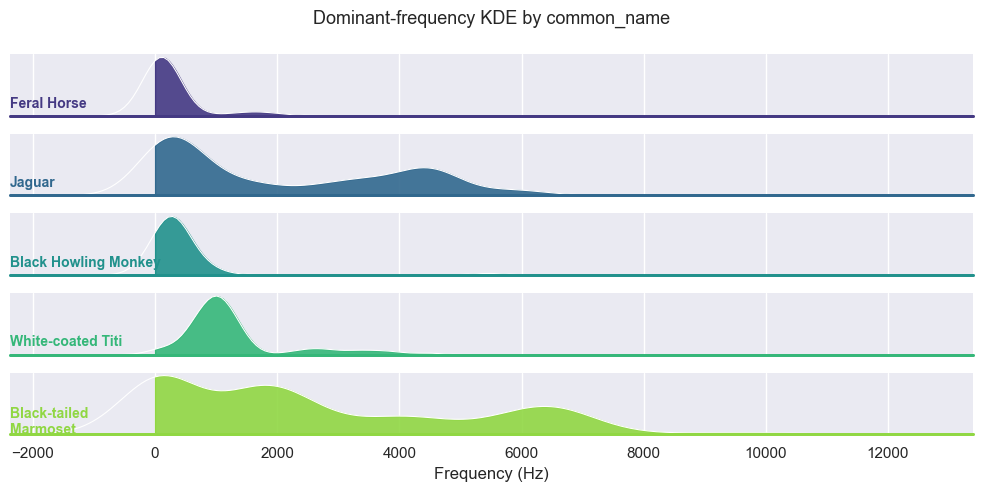

In [9]:
plot_df_subset = sample_primary_label(plot_df, "Mammalia", n=5)
fig = plot_kde(plot_df_subset, "common_name")
fig.savefig("plots/profiles/kde_mammalia.pdf", bbox_inches="tight")

## Profiles

In [10]:
profiles = np.load(paths.profiles_dir / "species_profiles.npy")
species_ids = np.load(paths.profiles_dir / "species_profile_ids.npy")
primary_to_class = np.load(paths.primary_to_class / "primary_to_class.npy")

le_primary_label = joblib.load(paths.label_encoders_dir / "primary_label.joblib")
le_class_name = joblib.load(paths.label_encoders_dir / "class_name.joblib")

#species_ids = le_primary_label.inverse_transform(species_ids)

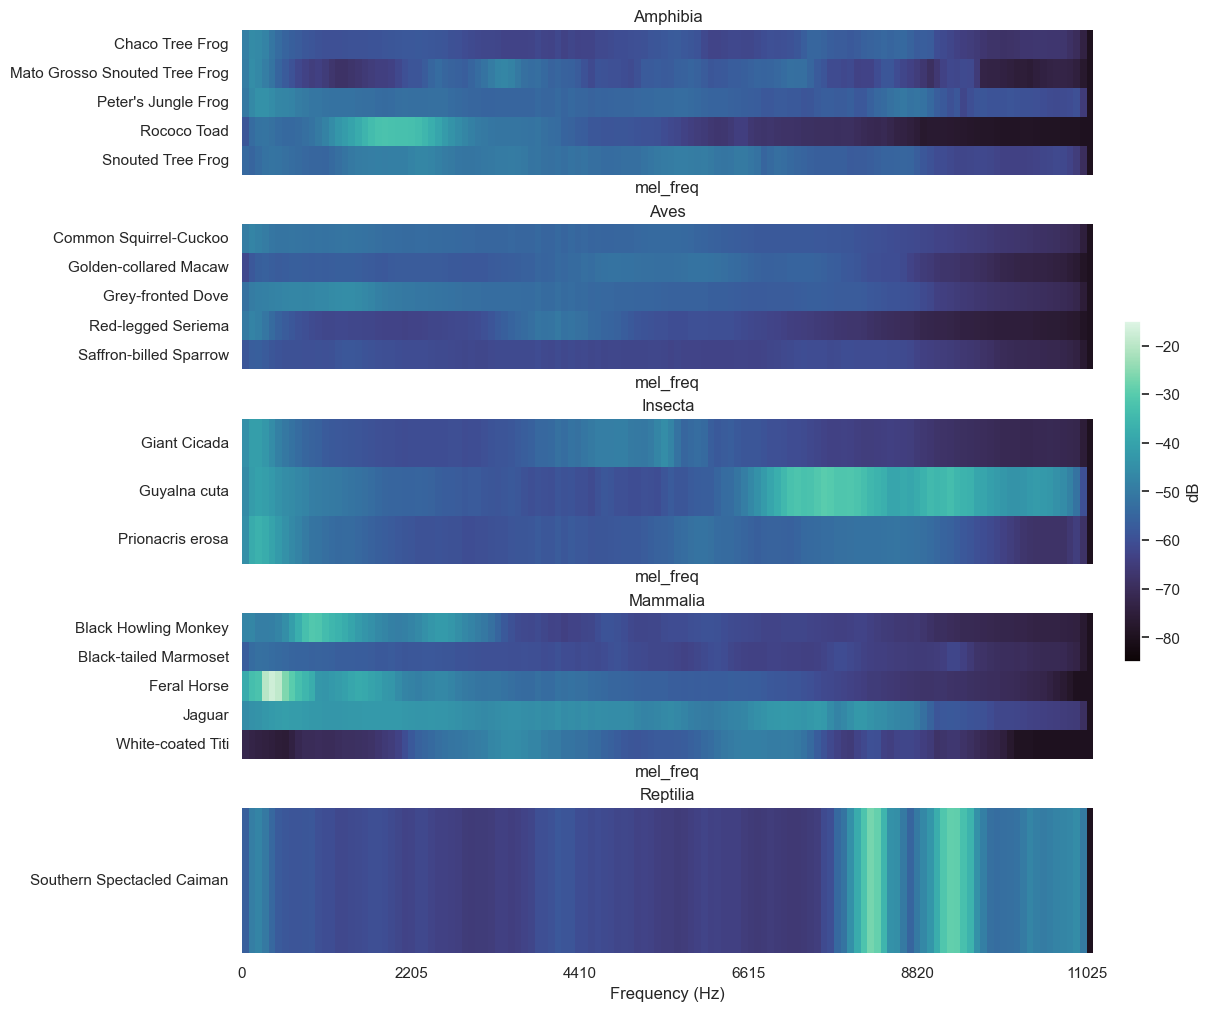

In [11]:
fig, axes = plt.subplots(
    5, 1,
    figsize=(12, 10),
    sharex=True,
    constrained_layout=True
)

# shared mel frequency axis
mel_freqs = np.array(librosa.mel_frequencies(128))
for i, class_name in enumerate(np.sort(train_df["class_name"].unique())):
    subset = sample_primary_label(
        train_df,
        class_name,
        n=5
    )["primary_label_int"].astype(int).unique()
    mask = np.isin(species_ids, subset)
    profiles_subset = pd.DataFrame({
        "profile": profiles[mask].tolist(),
        "primary_label": le_primary_label.inverse_transform(species_ids[mask])
    })

    profiles_subset = profiles_subset.merge(
        taxonomy[["primary_label", "common_name", "class_name"]],
        on="primary_label"
    )

    # attach frequency axis
    profiles_subset["mel_freq"] = [mel_freqs] * len(profiles_subset)

    # explode into scalar rows
    profiles_subset = profiles_subset.explode(["profile", "mel_freq"])

    # enforce numeric types (important for heatmap stability)
    profiles_subset["profile"] = pd.to_numeric(profiles_subset["profile"], errors="coerce")
    profiles_subset["mel_freq"] = pd.to_numeric(profiles_subset["mel_freq"], errors="coerce")

    # pivot to class profile matrix
    pivot = profiles_subset.pivot_table(
        index="common_name",
        columns="mel_freq",
        values="profile",
        aggfunc="mean"
    )
    # row_height = max(1.5, 0.3 * pivot.shape[0])

    # ax = fig.add_subplot(gs[i])
    # ax.set_box_aspect(row_height)
    
    # align all plots to same frequency grid
    pivot = pivot.reindex(columns=mel_freqs)
    sns.heatmap(
        pivot,
        ax=axes[i],
        cmap="mako",
        cbar=False,          # single shared colorbar
        xticklabels=False,
        yticklabels=True,
        vmin=-85, vmax=-15
    )   
    # if i == 0:
    #     cbar = axes[i].collections[0].colorbar
    #     cbar.set_label("dB", rotation=90)

    axes[i].set_title(class_name)
    axes[i].set_ylabel("")
    axes[i].tick_params(axis="y", labelrotation=0)
    axes[i].set_aspect("auto")
    
norm = mpl.colors.Normalize(vmin=-85, vmax=-15)
cmap = "mako"
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, orientation="vertical", fraction=0.02, pad=0.02)
cbar.set_label("dB")

# shared x-axis ticks only on bottom plot
n_ticks = 6
tick_pos = np.linspace(0, len(mel_freqs) - 1, n_ticks)
tick_labels = np.round(np.linspace(mel_freqs.min(), mel_freqs.max(), n_ticks), 0).astype(int)
axes[-1].set_xticks(tick_pos)
axes[-1].set_xticklabels(tick_labels)
axes[-1].set_xlabel("Frequency (Hz)")

fig.savefig("plots/profiles/profiles_heatmap.jpg", bbox_inches="tight", dpi=150)

### 5 seconds chunks

In [12]:
def plot_profile_similarity_heatmaps(
    dataset,
    profiles,
    species_ids,
    taxonomy,
    le_primary_label,
    row_idx,
    chunk_id,
    feature_prefix="mel_spectrogram_",
    feature_suffix="mean",
    vmin=-85,
    vmax=-15,
    cmap="mako",
):
    mel_mask = get_feature_indices(
        list(dataset.feature_names),
        prefix=feature_prefix,
        suffix=feature_suffix,
    )
    sims, _ = compute_profile_similarity_features(
        dataset.X[row_idx : row_idx + 1],
        dataset.feature_names,
        profiles,
        species_ids,
    )
    df = pd.DataFrame(data={
        "profile": profiles.tolist(),
        "similarity": sims[0].tolist(),
        "primary_label_int": species_ids,
        "primary_label": le_primary_label.inverse_transform(species_ids)
    })

    df = df.merge(taxonomy, on="primary_label").sort_values("similarity")
    most_row = df.tail(1).iloc[0]
    least_row = df.head(1).iloc[0]
    true_row = df[df["primary_label_int"] == dataset.y[row_idx, 1]].iloc[0]

    fig, axes = plt.subplots(
        4,
        1,
        figsize=(12, 5),
        sharex=True,
        constrained_layout=True,
    )
    row = dataset.X[row_idx]
    sns.heatmap(
        row[mel_mask].reshape(1, -1),
        vmin=vmin,
        vmax=vmax,
        cmap=cmap,
        cbar=False,
        ax=axes[0],
    )
    axes[0].set_title(f"{true_row["common_name"]}. Mel-spectrogram means. Chunk {chunk_id}")
    sns.heatmap(
        np.asarray(true_row["profile"]).reshape(1, -1),
        vmin=vmin,
        vmax=vmax,
        cmap=cmap,
        cbar=False,
        ax=axes[1],
    )
    axes[1].set_title(f"True species profile (cos={true_row["similarity"]:.3f})")

    sns.heatmap(
        np.asarray(most_row["profile"]).reshape(1, -1),
        vmin=vmin,
        vmax=vmax,
        cmap=cmap,
        cbar=False,
        ax=axes[2],
    )
    axes[2].set_title(f"Most similar: {most_row["common_name"]} (cos={most_row["similarity"]:.3f})")

    sns.heatmap(
        np.asarray(least_row["profile"]).reshape(1, -1),
        vmin=vmin,
        vmax=vmax,
        cmap=cmap,
        cbar=False,
        ax=axes[3],
    )
    axes[3].set_title(f"Least similar: {least_row["common_name"]} (cos={least_row["similarity"]:.3f})")

    for ax in axes:
        ax.set_yticks([])
        ax.set_ylabel("")
    axes[-1].set_xlabel("Mel bin")

    return fig

In [13]:
run_name = "run_chunks_overlap"
dataset = load_memmap_dataset(run_name, False, False)

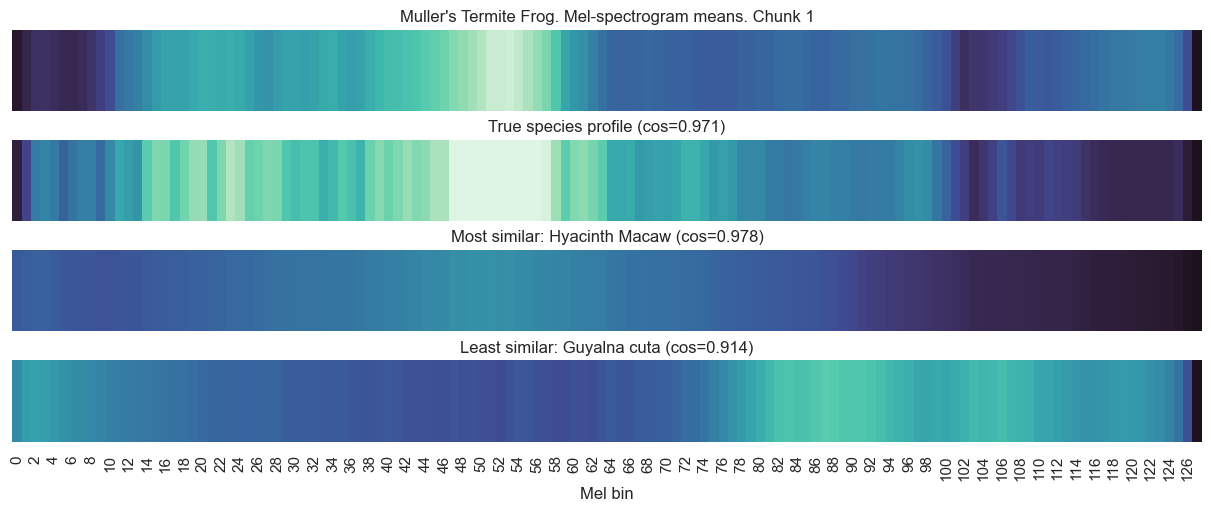

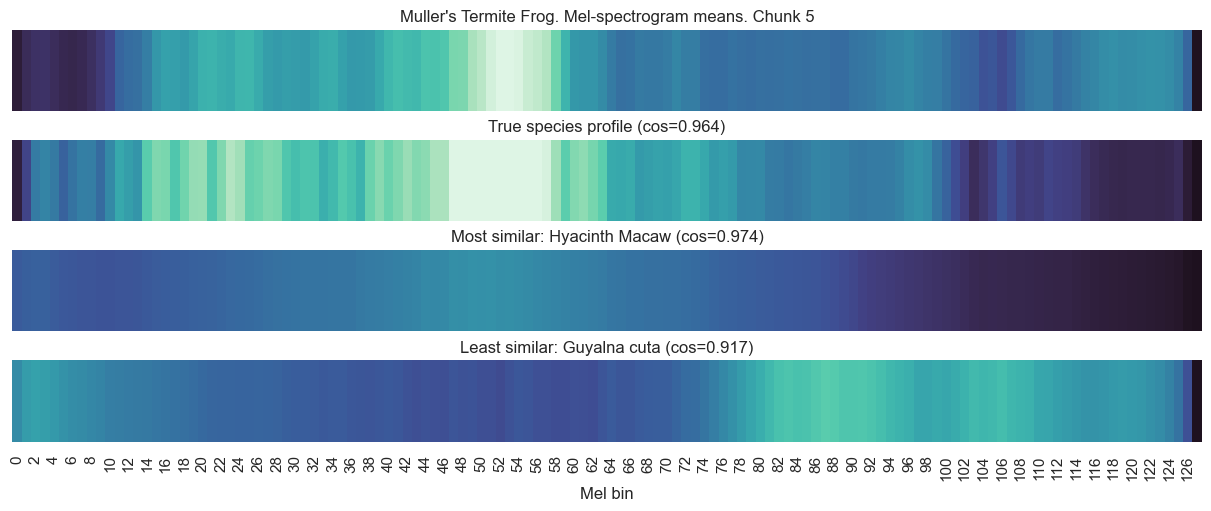

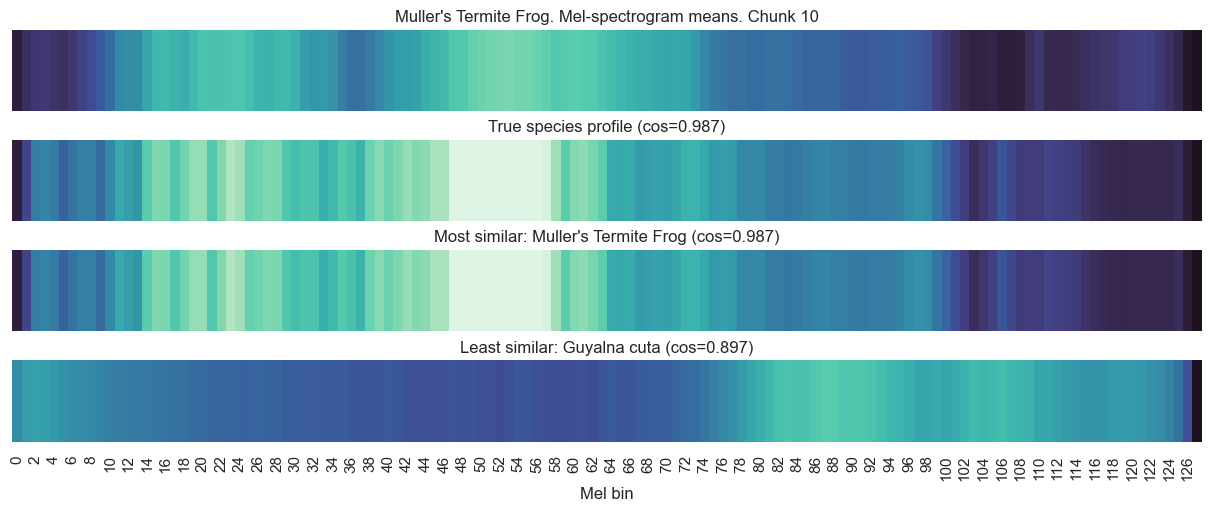

In [14]:
for idx, chunk_id in [(4523, 1), (4523+5, 5), (4523+10, 10)]:
    fig = plot_profile_similarity_heatmaps(
        dataset,
        profiles, 
        species_ids,
        taxonomy,
        le_primary_label,
        row_idx=idx, 
        chunk_id=chunk_id,
    )
    fig.savefig(f"plots/profiles/{run_name}_profile_cos_{idx}_chunk_{chunk_id}.jpg",
                bbox_inches="tight", dpi=150)

In [15]:
run_name = "run_mil"
dataset = load_memmap_dataset(run_name, False, False)

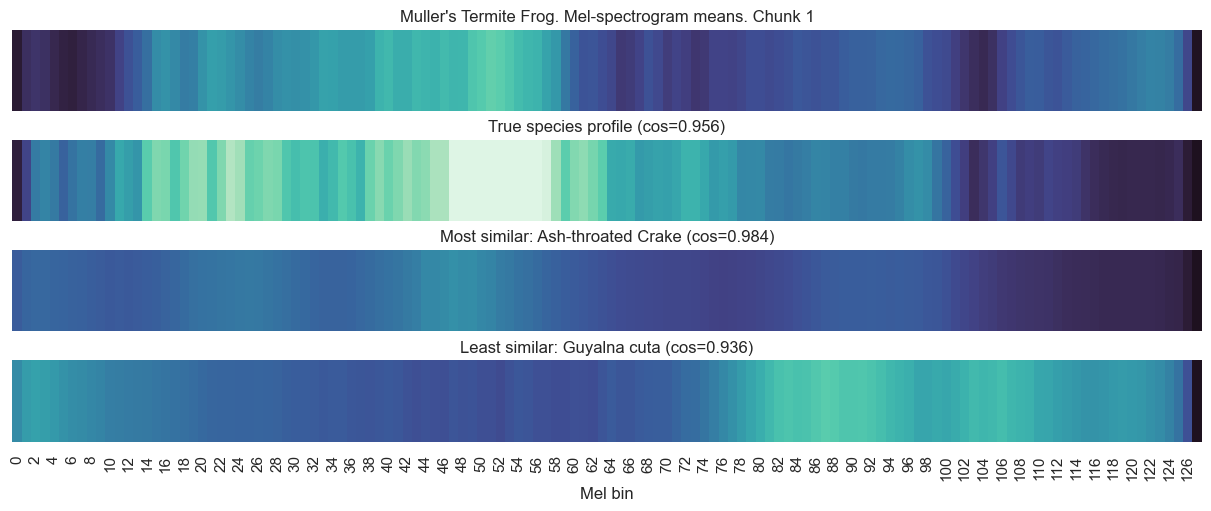

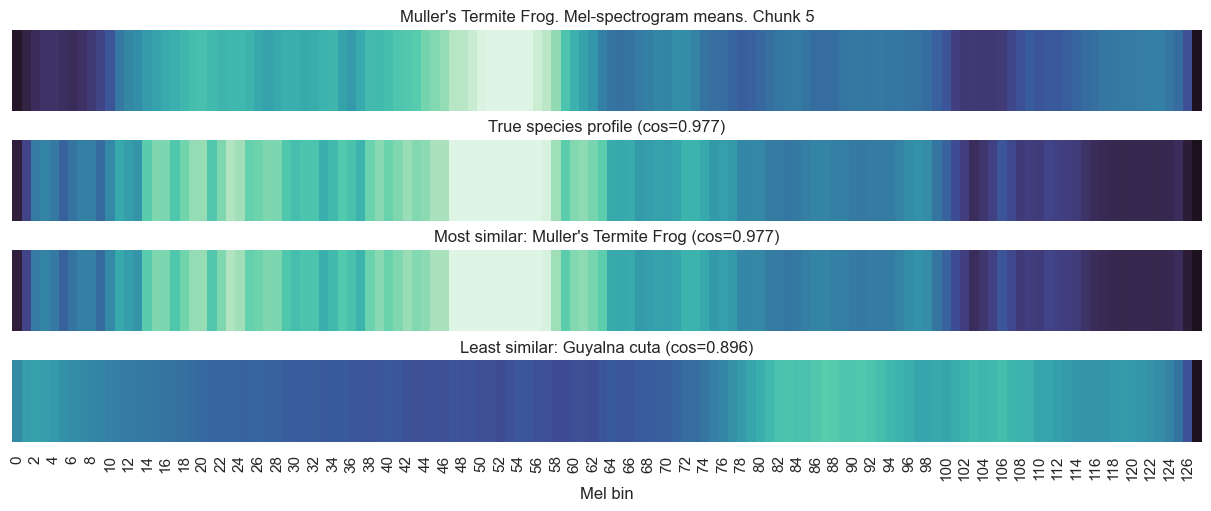

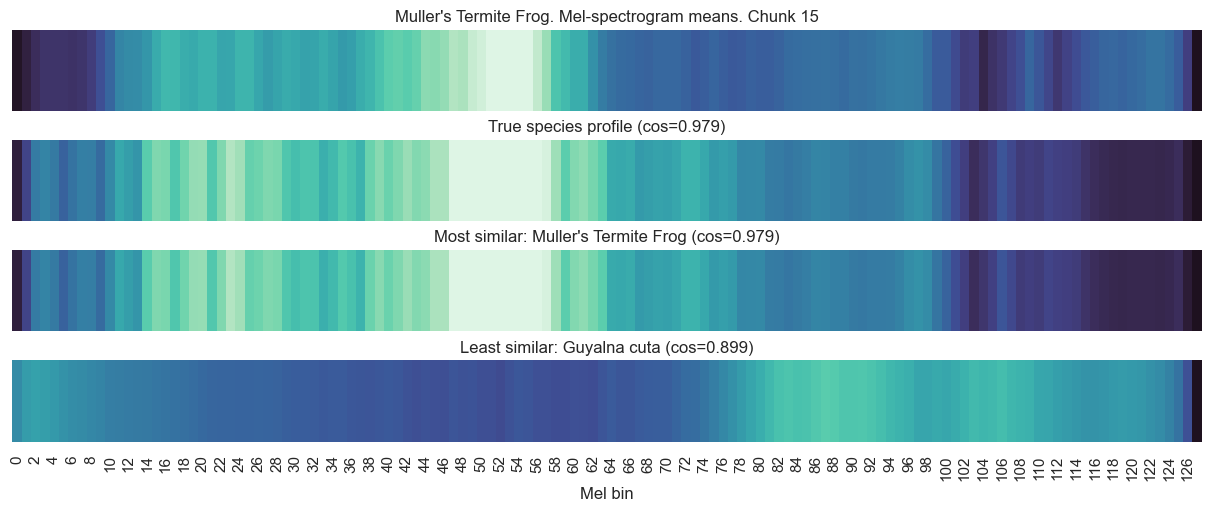

In [16]:
for idx, chunk_id in [(23090, 1), (23090+5, 5), (23090+15, 15)]:
    fig = plot_profile_similarity_heatmaps(
        dataset,
        profiles, 
        species_ids,
        taxonomy,
        le_primary_label,
        row_idx=idx, 
        chunk_id=chunk_id,
    )
    fig.savefig(f"plots/profiles/{run_name}_profile_cos_{idx}_chunk_{chunk_id}.jpg",
                bbox_inches="tight", dpi=150)